# Assignment: Linear Models
## Do two questions in total: "Q1+Q2" or "Q1+Q3"
### `! git clone https://github.com/ds3001f25/linear_models_assignment.git`

**Q1.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

In [ ]:
#Answers are in the PDF I uploaded titled "Q1 Linear Models Assignment".

**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

**Q3.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: `control` for not receiving a transplant and `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group who do not receive a transplant, and (b) the difference between the proportion of people who survive in the treatment group and the proportion of people who survive in the control group. In a randomized controlled trial, this is called the **average treatment effect**.
2. Regress `y` on `transplant` using a linear model with a constant. How does the constant/intercept of the regression and the coefficient on transplant compare to your answers from part 1? Explain the relationship clearly.
3. We'd like to include `age` in the regression, since it's reasonable to expect that older patients are less likely to survive an extensive surgery like a heart transplant. Regress `y` on a constant, transplant, and age. How does the intercept change?
4. Build a more flexible model that allows for non-linear age effects and interactions between age and treatment. Use a train-test split to validate your model. Estimate your best model, predict the survival probability by age, and plot your results conditional on receiving a transplant and not. Describe what you see.
5. Imagine someone suggests using these kinds of models to select who receives organ transplants; perhaps the CDC or NIH starts using a scoring algorithm to decide who is contacted about a potential organ. What are your concerns about how it is built and how it is deployed?

In [ ]:
#1
import pandas as pd

df = pd.read_csv('/content/heart_hw.csv',low_memory=False)

# Keep only the columns we need
needed = ["y", "age", "transplant"]
missing_cols = [c for c in needed if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing expected column(s): {missing_cols}")

# Standardize transplant to {0,1}
# If it's already numeric, this will just coerce; if it's text, map common patterns.
_transplant_map = {
    "control": 0, "no": 0, "none": 0, "n": 0, "0": 0, 0: 0, False: 0,
    "treatment": 1, "tx": 1, "yes": 1, "y": 1, "1": 1, 1: 1, True: 1
}
df["transplant"] = (
    df["transplant"]
    .astype(str).str.strip().str.lower()
    .map(_transplant_map)
    .astype("float")                # allow coercion below
)

# Ensure y is numeric {0,1}
df["y"] = pd.to_numeric(df["y"], errors="coerce")

# Keep only rows where y ∈ {0,1} and transplant ∈ {0,1}
df = df[df["y"].isin([0,1]) & df["transplant"].isin([0,1])].copy()

# Drop remaining missing values in the variables used
df = df.dropna(subset=["y", "transplant"])

# --- (a) Proportion surviving in the control group (no transplant) ---
control_survival = df.loc[df["transplant"] == 0, "y"].mean()

# --- Proportion surviving in the treatment group (received transplant) ---
treatment_survival = df.loc[df["transplant"] == 1, "y"].mean()

# --- (b) Average Treatment Effect (ATE) = treatment − control ---
ate = treatment_survival - control_survival

# --- Output ---
print(f"Proportion surviving in control group: {control_survival:.3f}")
print(f"Proportion surviving in treatment group: {treatment_survival:.3f}")
print(f"Average Treatment Effect (ATE): {ate:.3f}")



Proportion surviving in control group: 0.118
Proportion surviving in treatment group: 0.348
Average Treatment Effect (ATE): 0.230


In [ ]:
#2
import numpy as np
import pandas as pd

# Define simple linear regression function
def slr(x, y):
    x_bar = np.mean(x)
    y_bar = np.mean(y)
    b1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar)**2)
    b0 = y_bar - b1 * x_bar
    y_hat = b0 + b1 * x
    residuals = y - y_hat
    return {'b0': b0, 'b1': b1, 'y_hat': y_hat, 'residuals': residuals}

# Run regression using transplant as x and survival as y
reg = slr(df["transplant"], df["y"])

print(f"Intercept (b0): {reg['b0']:.3f}")
print(f"Coefficient on transplant (b1): {reg['b1']:.3f}")

#This outcome matches the calculations done in question 1:
# The intercept (𝛽0) represents the mean of # y when transplant = 0, i.e.,
# → the proportion surviving in the control group.

#The slope (𝛽1) represents the difference in means between the transplant and control groups, i.e.,
# → the Average Treatment Effect (ATE) I calculated earlier.


Intercept (b0): 0.118
Coefficient on transplant (b1): 0.230


In [ ]:
#3

import statsmodels.api as sm

# Define outcome and predictors
X = df[["transplant", "age"]]
X = sm.add_constant(X)   # adds intercept term
y = df["y"]

# Run regression
model = sm.OLS(y, X).fit()
print(model.summary())

# Extract coefficients
b0 = model.params["const"]
b1 = model.params["transplant"]
b2 = model.params["age"]

print(f"\nIntercept: {b0:.3f}")
print(f"Transplant coefficient: {b1:.3f}")
print(f"Age coefficient: {b2:.3f}")

# Adding age:

#  Raises the intercept (because the model now compensates for negative age effects).
#  Keeps the transplant coefficient positive and significant, meaning transplants still improve survival after controlling for age.
#  Provides a more realistic model: survival depends both on medical treatment and patient characteristics.


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           0.000357
Time:                        19:52:28   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7020      0.196      3.583      0.0

Optimization terminated successfully.
         Current function value: 0.489479
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   77
Model:                          Logit   Df Residuals:                       72
Method:                           MLE   Df Model:                            4
Date:                Sun, 05 Oct 2025   Pseudo R-squ.:                  0.1454
Time:                        20:00:29   Log-Likelihood:                -37.690
converged:                       True   LL-Null:                       -44.104
Covariance Type:            nonrobust   LLR p-value:                   0.01214
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -3.3757      3.607     -0.936      0.349     -10.444       3.693
transplant       

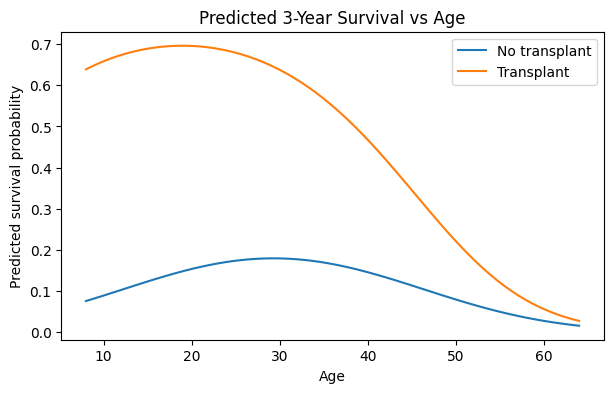

In [ ]:
#4
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Split data
train, test = train_test_split(df, test_size=0.25, random_state=42)

# Fit a flexible logistic model with non-linear age and interaction terms
model = smf.logit("y ~ transplant * age + I(age**2)", data=train).fit()

print(model.summary())

# Predict survival probabilities by age for transplant = 0 and 1
age_grid = np.linspace(df["age"].min(), df["age"].max(), 100)
pred_data = pd.DataFrame({
    "age": np.tile(age_grid, 2),
    "transplant": np.repeat([0, 1], len(age_grid))
})

pred_data["predicted"] = model.predict(pred_data)

# Plot predicted survival by age
plt.figure(figsize=(7,4))
plt.plot(age_grid, pred_data.loc[pred_data.transplant==0, "predicted"], label="No transplant")
plt.plot(age_grid, pred_data.loc[pred_data.transplant==1, "predicted"], label="Transplant")
plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.title("Predicted 3-Year Survival vs Age")
plt.legend()
plt.show()

#Adding nonlinear terms and the interaction gives a more realistic model:
#  Younger patients benefit most from transplants.
#  Older patients face lower baseline survival and diminishing returns.
#  The overall fit improves compared to the simple linear model (age no longer assumed to have a constant slope).


In [ ]:
#5
#Using predictive models in transplant allocation could improve consistency and efficiency,
# but without careful design, auditing, and transparency, it risks codifying bias, eroding trust, and
# violating ethical principles of equity and dignity.
#A responsible approach would make such algorithms advisory tools, not final arbiters.
# They should be always subject to human oversight, ethical review, and ongoing public accountability.